In [52]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from utilsforecast.preprocessing import fill_gaps
from tinyshift.stats import remove_leading_zeros, is_obsolete
from tinyshift.plot import stationarity_analysis, pami, residual_analysis, MSTLDiagnostics
import pandas as pd
import numpy as np
from statsforecast.models import SeasonalNaive, AutoETS
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from mlforecast import MLForecast
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, bias
from tinyshift.series import SeasonalityAnalyzer
from tinyshift.forecasting import wape, pbias, score, forecast_instability, rmae 
from tinyshift.forecasting import DMSTLWrapper
from mlforecast.utils import PredictionIntervals

In [17]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df["unique_id"] = "1"
df.rename(columns={"Month": "ds", "Passengers": "y"}, inplace=True)
df = fill_gaps(df, freq="ME", end="per_serie", id_col="unique_id", time_col="ds")
df = df.groupby("unique_id")[df.columns].apply(remove_leading_zeros).reset_index(drop=True)
days_obsoletes=180
obsolete_series = df.groupby("unique_id")[df.columns].apply(is_obsolete, days_obsoletes)
obsolote_ids = obsolete_series[obsolete_series].index.tolist()
assert len(obsolote_ids) == 0, f"Obsolete series found: {obsolote_ids}"

In [18]:
metrics = [rmse, mae, bias, wape, pbias, score, forecast_instability]

In [19]:
df.isnull().sum()

unique_id    0
ds           0
y            0
dtype: int64

## MSTL + ML

In [20]:
horizon = 12
train = df[:-horizon]
test = df[-horizon:]

In [21]:
periods = (
    SeasonalityAnalyzer(top_k=2, noise_threshold_factor=2.0)
    .fit(df)
    .results_["1"]["significant_periods"]
)

In [22]:
periods

[6, 12]

In [53]:
diagnostics = MSTLDiagnostics(periods=periods).fit(df["y"])

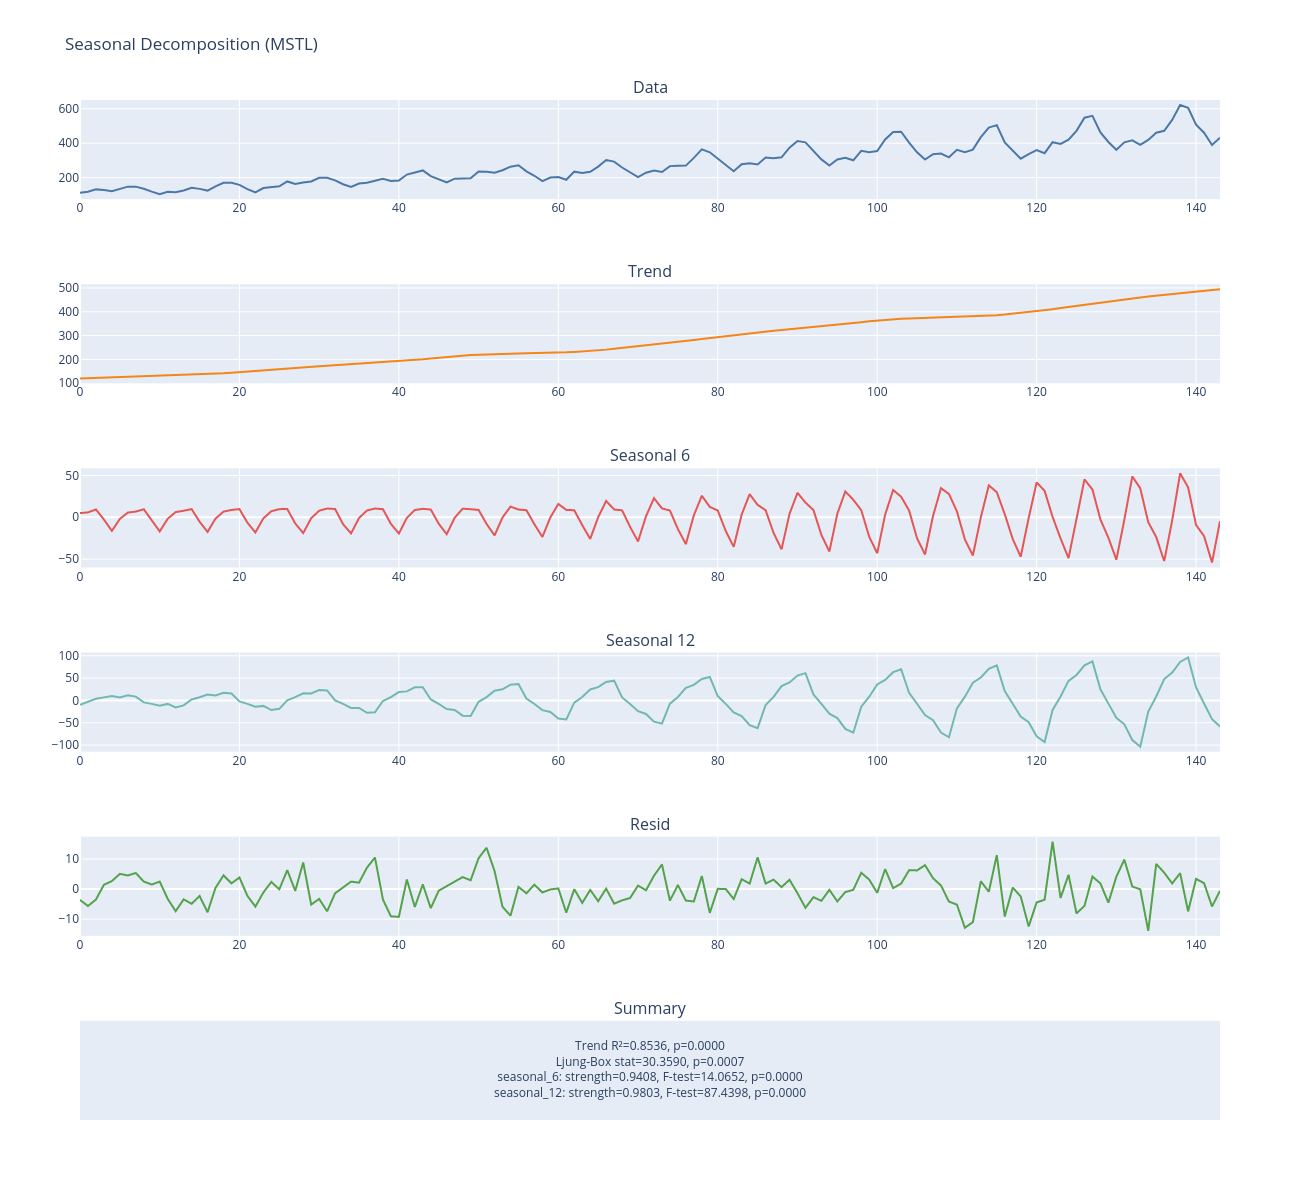

In [54]:
diagnostics.plot(fig_type="png")

In [55]:
models = [LinearRegression(), RandomForestRegressor(n_estimators=100, random_state=42)]

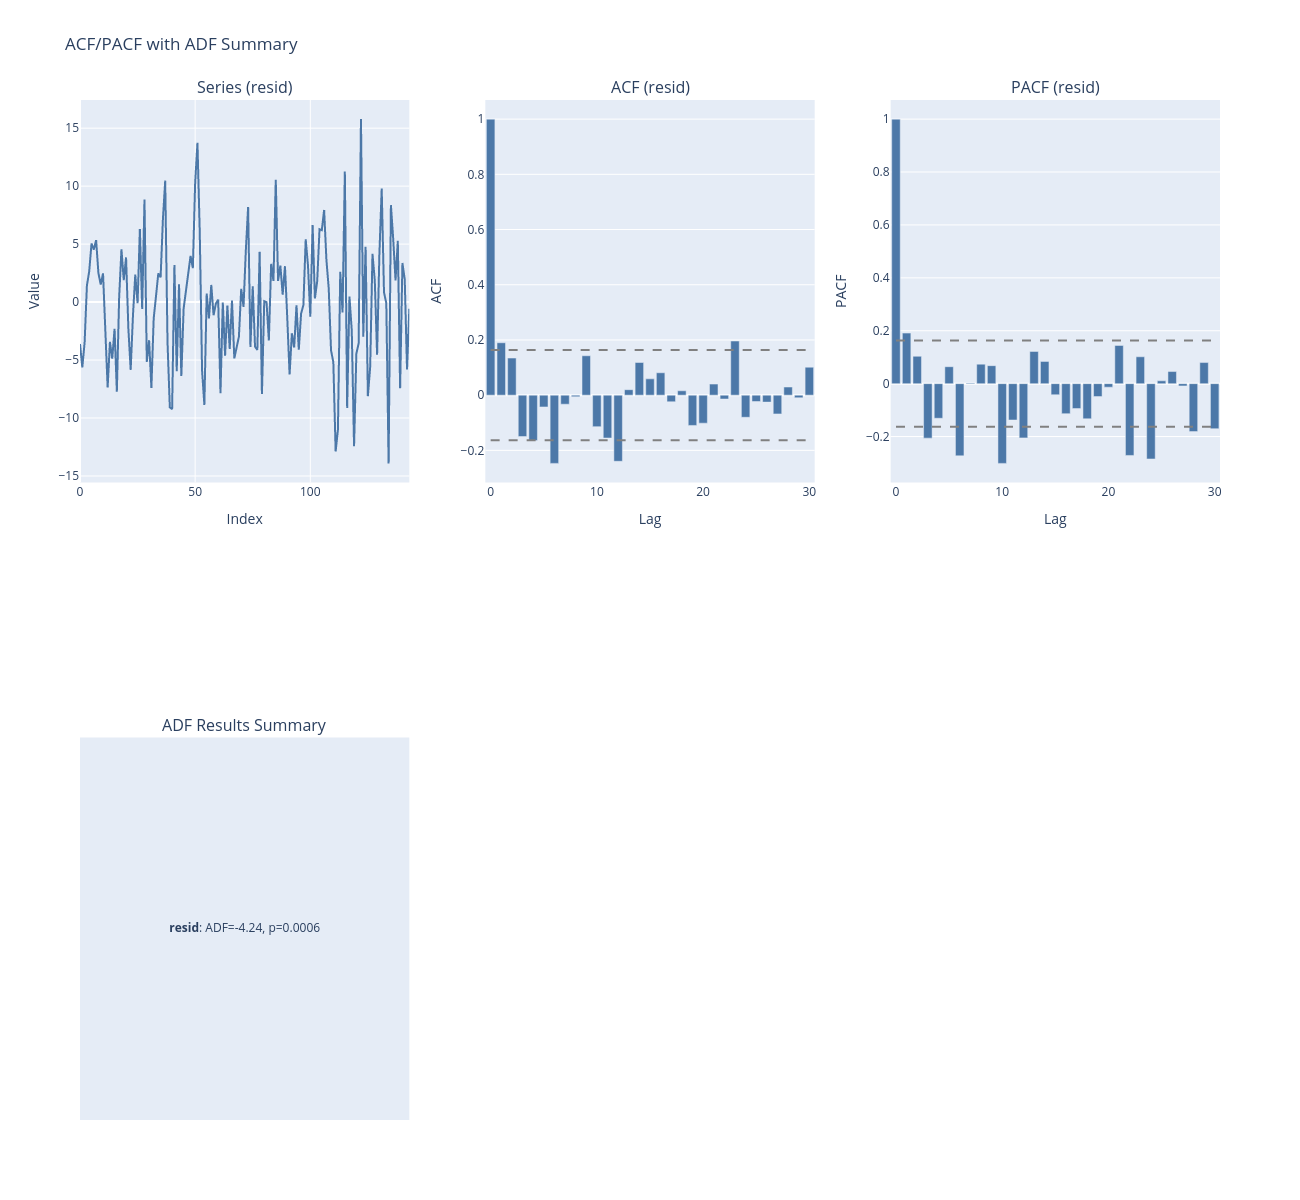

In [56]:
stationarity_analysis(diagnostics.components_["resid"], nlags=30, fig_type="png")

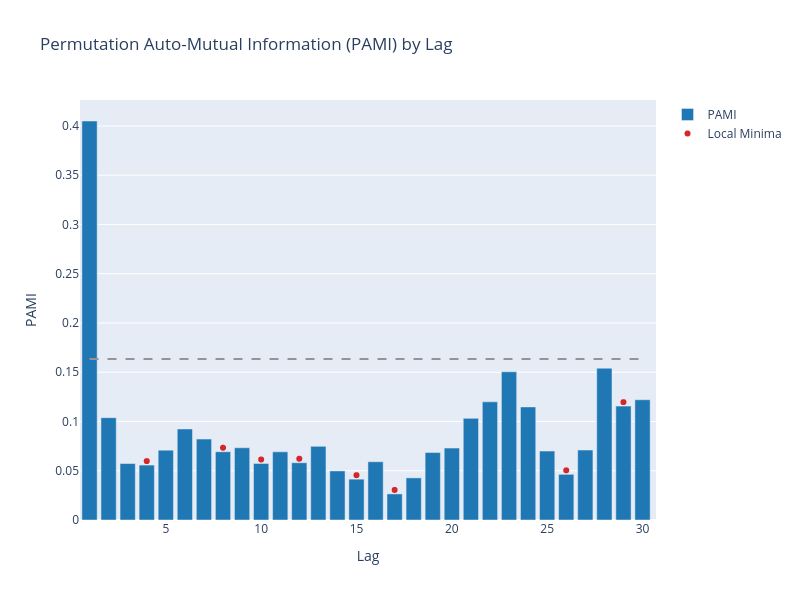

In [57]:
pami(diagnostics.components_["resid"], nlags=30, fig_type="png", m=3, normalize=True)

In [58]:
def seasonal_callable(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )


def trend_model_callable():
    return AutoETS(
        model="ZAN",
        alias="Trend-AutoETS",
    )


def residual_model_callable(nlags, freq):
    return MLForecast(
        models=models,
        lags=nlags,
        freq=freq,
    )


dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=periods,
    trend_model_callable=trend_model_callable,
    seasonal_model_callable=seasonal_callable,
    nlags=[1, 4],
)

In [59]:
dmstl.fit(train[["unique_id", "ds", "y"]], target_col="y")

,mode,'global'
,residual_model_callable,<function res...x78c8f21e8400>
,freq,'MS'
,season_length,"[6, 12]"
,seasonal_detection_params,None
,trend_model_callable,<function tre...x78c8f21e9120>
,seasonal_model_callable,<function sea...x78c8f21ea160>
,nlags,"[1, 4]"
,pami_params,None
,log_transform,False


In [60]:
result = dmstl.predict(h=12)
result["y"] = test["y"].values

In [61]:
evaluate(result, 
         metrics=metrics, 
         models=["LinearRegression", "RandomForestRegressor"], 
         id_col="unique_id", 
         time_col="ds", 
         target_col="y")

,unique_id,metric,LinearRegression,RandomForestRegressor
0,1,rmse,18.956181,19.797320
1,1,mae,15.455444,15.157097
2,1,bias,10.242189,10.362945
3,1,wape,0.032458,0.031831
4,1,pbias,0.021510,0.021763
5,1,score,0.053968,0.053595
6,1,forecast_instability,0.093284,0.093724


In [62]:
result["residual_dmstl_lr"] = result["y"].values - result["LinearRegression"].values
result["residual_dmstl_rf"] = result["y"].values - result["RandomForestRegressor"].values

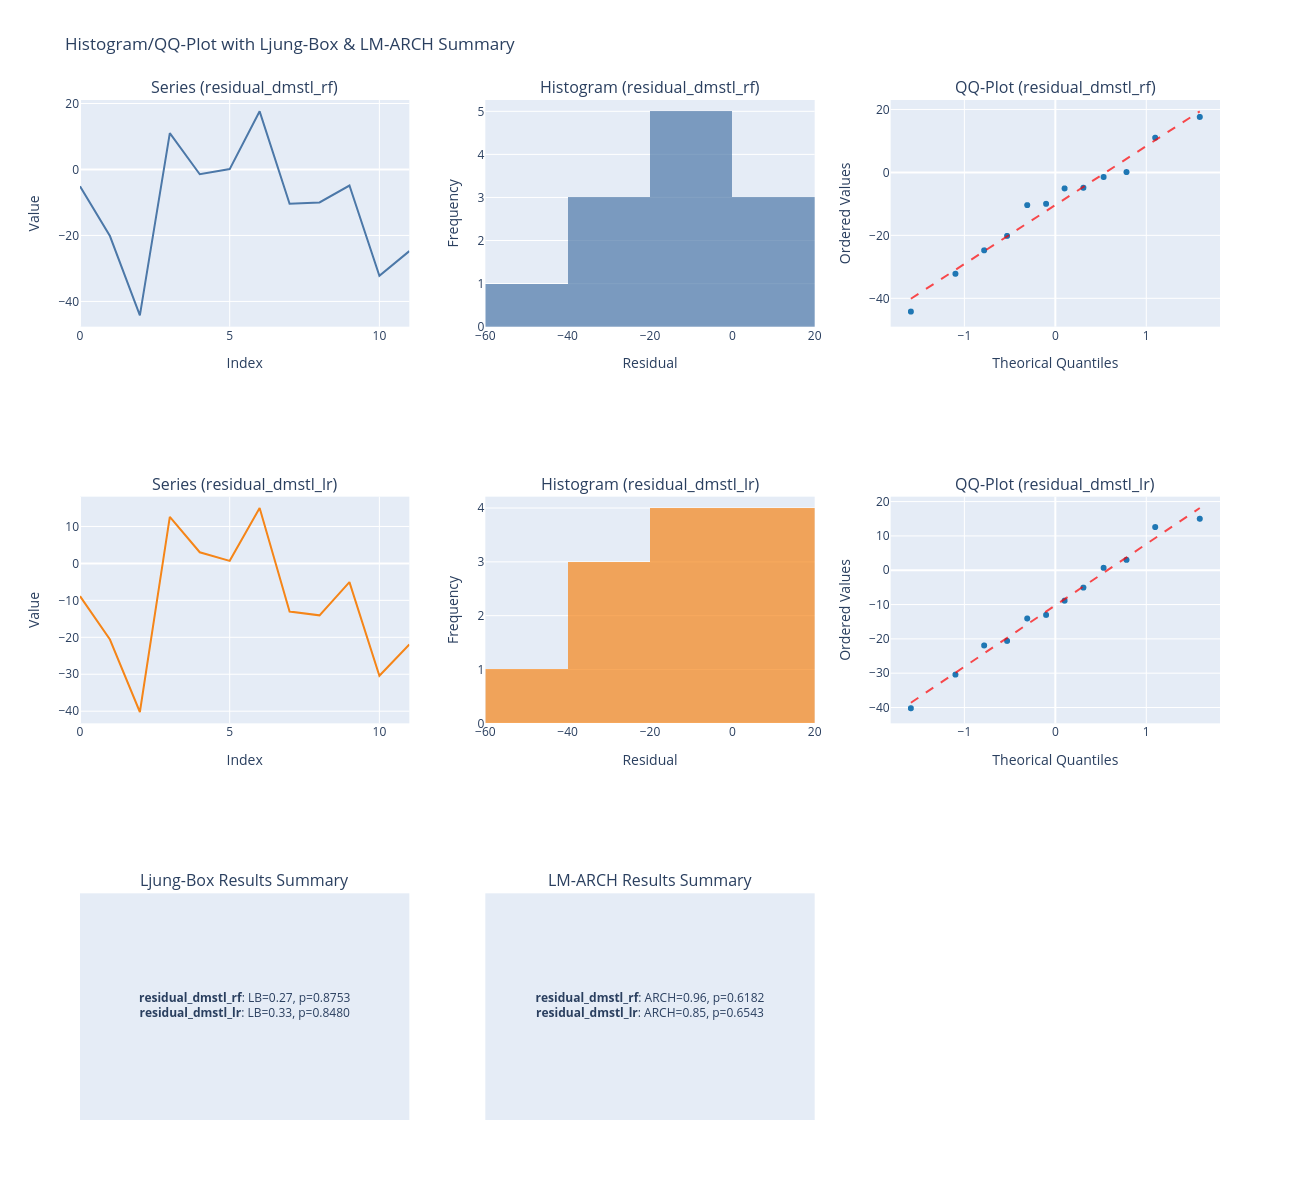

In [63]:
residual_analysis(result[["residual_dmstl_rf", "residual_dmstl_lr"]], nlags=30, fig_type="png")

In [64]:
naive_evaluation = result.assign(
    naive=result.groupby("unique_id", observed=True)["y"].shift(1)
).dropna(subset=["naive"])
rmae(naive_evaluation, models=["RandomForestRegressor"], baseline_col="naive")

,unique_id,metric,RandomForestRegressor
0,1,rmae,0.332955


In [65]:
moving_average_evaluation = result.assign(
    moving_average=result.groupby("unique_id", observed=True)["y"].transform(
        lambda values: values.rolling(3).mean().shift(1)
    )
).dropna(subset=["moving_average"])
rmae(
    moving_average_evaluation,
    models=["RandomForestRegressor"],
    baseline_col="moving_average",
)

,unique_id,metric,RandomForestRegressor
0,1,rmae,0.153218


# Prediction Intervals

In [66]:
def callable_autoets(period):
    return AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    )


prediction_intervals = PredictionIntervals(
    n_windows=3,
    h=14,
)
dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=periods,
    seasonal_model_callable=callable_autoets,
    nlags=[1, 5],
)
dmstl.fit(
    train[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)
forecasts = dmstl.predict(
    h=14,
    level=[95],
)

In [67]:
evaluate(result,
         metrics=metrics,
         models=["RandomForestRegressor"],
         id_col="unique_id",
         time_col="ds",
         target_col="y")

,unique_id,metric,RandomForestRegressor
0,1,rmse,19.797320
1,1,mae,15.157097
2,1,bias,10.362945
3,1,wape,0.031831
4,1,pbias,0.021763
5,1,score,0.053595
6,1,forecast_instability,0.093724


## Per-SKU Seasonal Periods with DMSTLWrapper

`DMSTLWrapper` accepts a dictionary when different series require different seasonal periods. Each key must match a `unique_id`, and each value can be a single period or a list of periods.

The first configuration below is explicit. The second one uses `SeasonalityAnalyzer` on the complete panel and passes its per-SKU result to `DMSTLWrapper`.


In [68]:
panel = pd.concat(
    [
        train.assign(unique_id="sku-a"),
        train.assign(unique_id="sku-b"),
    ],
    ignore_index=True,
)

manual_season_lengths = {
    "sku-a": [7, 30],
    "sku-b": 12,
}
trend_model_callable = {
    "sku-a": lambda: AutoETS(model="ZZN", alias="Trend-sku-a"),
    "sku-b": lambda: AutoETS(model="ZNN", alias="Trend-sku-b"),
}
manual_dmstl = DMSTLWrapper(
    mode="local",
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length=manual_season_lengths,
    trend_model_callable=trend_model_callable,
    nlags={"sku-a": [1, 2, 3], "sku-b": "auto"},
    pami_params={"max_tau": 24, "m": 3, "delay": 1, "mode": "point"},
)
manual_dmstl.fit(panel[["unique_id", "ds", "y"]], target_col="y")

manual_season_lengths

{'sku-a': [7, 30], 'sku-b': 12}

In [69]:
manual_dmstl.fitted_models_

{'sku-a': {'trend': StatsForecast(models=[Trend-sku-a]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-7]),
   StatsForecast(models=[SeasonalNaive-30])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag1', 'lag2', 'lag3'], date_features=[], num_threads=1)},
 'sku-b': {'trend': StatsForecast(models=[Trend-sku-b]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-12])],
  'residual': MLForecast(models=[LinearRegression, RandomForestRegressor], freq=MS, lag_features=['lag3'], date_features=[], num_threads=1)}}

In [70]:
seasonal_model_callable = {
    "sku-a": lambda period: AutoETS(
        season_length=period,
        model="ZNA",
        alias=f"AutoETS-{period}",
    ),
    "sku-b": lambda period: SeasonalNaive(
        season_length=period,
        alias=f"SeasonalNaive-{period}",
    ),
}
detected_dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_callable,
    freq="MS",
    season_length="auto",
    seasonal_detection_params={
        "top_k": 2,
        "significance_level": 0.05,
        "fallback": 12,
    },
    seasonal_model_callable=seasonal_model_callable,
    nlags="auto",
    pami_params={"mode": "range"}
)
detected_dmstl.fit(
    panel[["unique_id", "ds", "y"]],
    target_col="y",
    prediction_intervals=prediction_intervals,
)


,mode,'global'
,residual_model_callable,<function res...x78c8f21e8400>
,freq,'MS'
,season_length,'auto'
,seasonal_detection_params,"{'fallback': 12, 'significance_level': 0.05, 'top_k': 2}"
,trend_model_callable,None
,seasonal_model_callable,"{'sku-a': <function <la...x78c8f24a44a0>, 'sku-b': <function <la...x78c8f24a6340>}"
,nlags,'auto'
,pami_params,{'mode': 'range'}
,log_transform,False


In [71]:
detected_dmstl.fitted_models_

{'sku-a': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[AutoETS-6]),
   StatsForecast(models=[AutoETS-12])]},
 'sku-b': {'trend': StatsForecast(models=[AutoETS]),
  'seasonal': [StatsForecast(models=[SeasonalNaive-6]),
   StatsForecast(models=[SeasonalNaive-12])]}}

In [72]:
result = detected_dmstl.predict(h=12)

In [73]:
result = detected_dmstl.predict(h=12)
result = result[result["unique_id"] == "sku-a"]
result["y"] = test["y"].values
evaluate(result,
         metrics=metrics,
         models=["RandomForestRegressor"],
         id_col="unique_id",
         time_col="ds",
         target_col="y")

,unique_id,metric,RandomForestRegressor
0,sku-a,rmse,19.747635
1,sku-a,mae,15.591610
2,sku-a,bias,12.895812
3,sku-a,wape,0.032744
4,sku-a,pbias,0.027083
5,sku-a,score,0.059827
6,sku-a,forecast_instability,0.090839


## DMSTL with exog features

In [74]:
exog_train = train[["unique_id", "ds", "y"]].copy()
exog_train["promotion"] = exog_train["ds"].dt.month.isin([3, 9]).astype(float)


def residual_model_with_exog(nlags, freq):
    return MLForecast(
        models=[LinearRegression()],
        lags=nlags,
        freq=freq,
    )


exog_dmstl = DMSTLWrapper(
    residual_model_callable=residual_model_with_exog,
    freq="MS",
    season_length=periods,
    trend_model_callable=trend_model_callable,
    seasonal_model_callable=seasonal_callable,
    nlags=[1, 5],
)

exog_dmstl.fit(
    exog_train,
    target_col="y",
    static_features=[],
)
exog_dmstl.exog_cols_

['promotion']

In [75]:
exog_future = test[["unique_id", "ds"]].copy()
exog_future["promotion"] = exog_future["ds"].dt.month.isin([3, 9]).astype(float)

exog_forecasts = exog_dmstl.predict(
    h=horizon,
    X_df=exog_future,
)

exog_forecasts

,unique_id,ds,LinearRegression
0,1,1960-01-01,425.897582
1,1,1960-02-01,411.492883
2,1,1960-03-01,459.200933
3,1,1960-04-01,449.806007
4,1,1960-05-01,468.841286
5,1,1960-06-01,534.114958
6,1,1960-07-01,606.911241
7,1,1960-08-01,618.754040
8,1,1960-09-01,521.862138
9,1,1960-10-01,466.037419


## Saving and Loading a DMSTL Model

`DMSTLWrapper` is a plain scikit-learn compatible estimator, so it can be persisted with `joblib`, which is already a `tinyshift` dependency. This preserves every fitted StatsForecast and MLForecast model held internally, for both `mode="local"` and `mode="global"`.

In [76]:
import joblib

model_path = "dmstl_model.joblib"

# Save the fitted wrapper (works the same for mode="local" or mode="global").
joblib.dump(dmstl, model_path)

# Load it back into a new object.
loaded_dmstl = joblib.load(model_path)

loaded_forecast = loaded_dmstl.predict(h=12)
loaded_forecast.head()

,unique_id,ds,LinearRegression,RandomForestRegressor
0,1,1960-01-01,425.904497,423.040588
1,1,1960-02-01,411.501287,415.599371
2,1,1960-03-01,459.171643,464.551089
3,1,1960-04-01,449.804051,453.055525
4,1,1960-05-01,468.847335,470.106878
